In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('/content/Country-data.csv')

In [ ]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
from sklearn.preprocessing import StandardScaler

#prepare feature(drop non numeric 'country' column)
features = df.drop('country', axis=1)

#Scale
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)
scaled_df = pd.DataFrame(scaled_data, columns=features.columns)
scaled_df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)

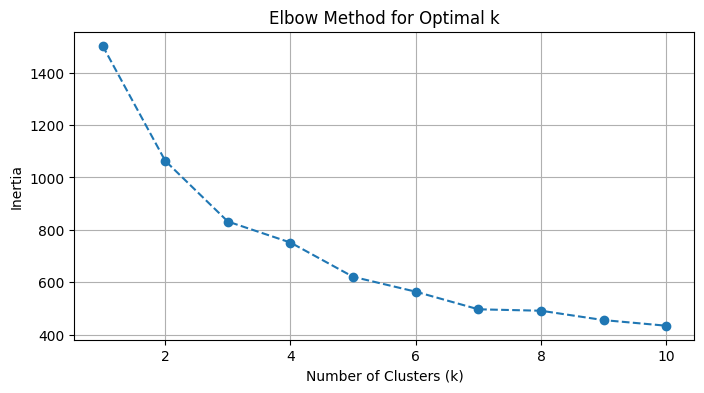

In [8]:
#Visualize the Elbow
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [9]:
from sklearn.cluster import KMeans, DBSCAN

# Apply kmeans with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(scaled_df)

# Apply DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=3)
df['dbscan_cluster'] = dbscan.fit_predict(scaled_df)

print("Clustering complete")
print(df.head())




Clustering complete
               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  kmeans_cluster  dbscan_cluster  
0       9.44        56.2       5.82    553               2               0  
1       4.49        76.3       1.65   4090               0               0  
2      16.10        76.5       2.89   4460               0               0  
3      22.40        60.1       6.16   3530               2              -1  
4       1.44        76.8       2.13  12200               0               0  


In [10]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Split data- Features (scaled_df) and Target (the k-means labels)
X = scaled_df
y = df['kmeans_cluster']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# Random Forest(bagging)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         6

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



In [12]:
xgb = GradientBoostingClassifier( random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print("XGBoost Classification Report:")
print(classification_report(y_test, xgb_pred))



XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         6

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



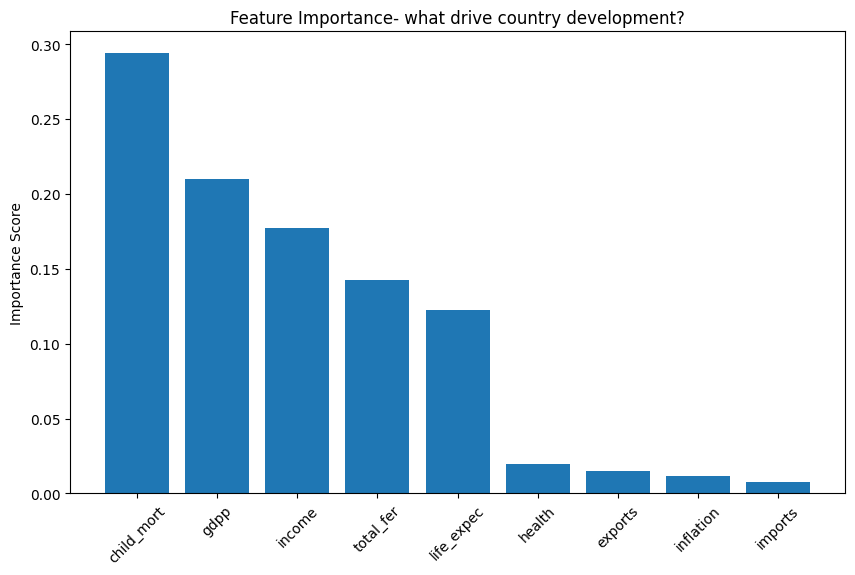

In [13]:
# visualize feature importance
imprtances = rf.feature_importances_
indices = np.argsort(imprtances)[::-1]
features_names = features.columns

plt.figure(figsize=(10, 6))
plt.title("Feature Importance- what drive country development?")
plt.bar(range(X.shape[1]), imprtances[indices], align="center")
plt.xticks(range(X.shape[1]), features_names[indices], rotation=45)
plt.ylabel("Importance Score")
plt.show()



#PCA Visualization(how are the clusters spread?)

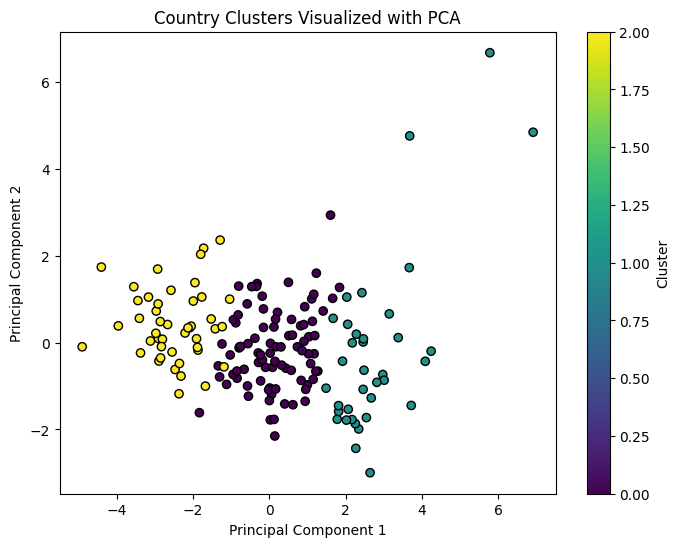

In [14]:
# pca visualization

from sklearn.decomposition import PCA

# Reduce to 2 dimension for visualization
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_df)

# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=df['kmeans_cluster'], cmap='viridis', edgecolors='k')
plt.title('Country Clusters Visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.show()



#Country-Level Insights


In [15]:
# check the clusters average
print(df.groupby('kmeans_cluster')[['child_mort', 'gdpp', 'income']].mean())



                child_mort          gdpp        income
kmeans_cluster                                        
0                22.456977   6461.767442  12321.744186
1                 5.000000  42494.444444  45672.222222
2                95.106667   1766.711111   3539.844444


#"By analyzing the cluster means, we identified Cluster 2 as the priority segment for aid, as it exhibits the highest child mortality rate (95.1) and lowest GDP (1766) among all groups."

In [18]:
# cluster 2 is in more vulnerable state
high_need_countries = df[df['kmeans_cluster'] == 2][['country','gdpp']]
print("Top Countries in direst need of aid (Cluster 2):")
print(high_need_countries.sort_values(by='gdpp', ascending=True))


Top Countries in direst need of aid (Cluster 2):
                      country   gdpp
26                    Burundi    231
88                    Liberia    327
37           Congo, Dem. Rep.    334
112                     Niger    348
132              Sierra Leone    399
93                 Madagascar    413
106                Mozambique    419
31   Central African Republic    446
94                     Malawi    459
50                    Eritrea    482
150                      Togo    488
64              Guinea-Bissau    547
0                 Afghanistan    553
56                     Gambia    562
126                    Rwanda    563
25               Burkina Faso    575
155                    Uganda    595
63                     Guinea    648
66                      Haiti    662
147                  Tanzania    702
97                       Mali    708
17                      Benin    758
36                    Comoros    769
32                       Chad    897
80                      Ke